$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{February 27, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 5: Linear Regression}
\end{array}
$$

---

![Linear Regression](../figures/LR_lab5_image1.png)

---

# Recitation: OLS Fit for SLR & Multiple Linear Regression

## Today's Outline

1. **R² — Measuring Model Fit**: TSS, ESS, SSR decomposition; what R² tells us (and doesn't)
2. **R² in Practice**: IMDB data — comparing budget vs. duration as predictors of movie revenue
3. **Training/Test Splits & MSE**: Out-of-sample evaluation of predictive performance
4. **Multiple Linear Regression**: Generalizing from SLR to multiple regressors; vector notation
5. **MLR in Practice**: NYC housing data — why multiple features improve prediction
6. **Frisch-Waugh-Lovell Theorem**: Interpreting individual coefficients in MLR; the "residualized regression" idea

---

## 1. R² — Measuring Model Fit

How well does our estimated regression model explain the data used to estimate it?

### Notation 

- $\hat{\beta}_0, \hat{\beta}_1$: our **OLS estimates** of the true parameters $\beta_0, \beta_1$ — computed from the sample
- $\hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_i$: the **predicted value** of $Y_i$ according to our estimated model (the "hat" denotes something estimated or predicted)
- $\hat{\varepsilon}_i = Y_i - \hat{Y}_i$: the **empirical residual** — how far observation $i$ is from the regression line
- $\bar{Y} = \frac{1}{n}\sum_{i=1}^n Y_i$: the **sample mean** of $Y$

### The Variance Decomposition

We can decompose the total variation in $Y$ into two pieces:

| Component | Formula | Meaning |
|-----------|---------|---------|
| **TSS** (Total Sum of Squares) | $\sum_{i=1}^n (Y_i - \bar{Y})^2$ | Total variation in $Y$ |
| **ESS** (Explained Sum of Squares) | $\sum_{i=1}^n (\hat{Y}_i - \bar{Y})^2$ | Variation "explained" by the model |
| **SSR** (Sum of Squared Residuals) | $\sum_{i=1}^n \hat{\varepsilon}_i^2$ | Variation **not** explained by the model |

A key result: $\text{TSS} = \text{ESS} + \text{SSR}$

The **R²** is the proportion of total variation explained by the model:

$$R^2 = \frac{\text{ESS}}{\text{TSS}} = 1 - \frac{\text{SSR}}{\text{TSS}}$$

- $R^2 = 1$: every data point falls exactly on the regression line ($\hat{Y}_i = Y_i$ for all $i$)
- $R^2 = 0$: the model has no explanatory power ($\hat{\beta}_1 = 0$, regression line is just $\bar{Y}$)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# We'll simulate an IMDB-like dataset that mirrors the lecture's results
np.random.seed(42)
n = 1841

# Budget in dollars (roughly 0 to 300M)
budget = np.random.exponential(scale=5e7, size=n)
budget = np.clip(budget, 1e6, 3e8)

# Duration in minutes (roughly 60 to 260)
duration = np.random.normal(loc=115, scale=25, size=n)
duration = np.clip(duration, 60, 270)

# Revenue: strongly related to budget, weakly related to duration, plus noise
revenue = (2.5 * budget 
           + 8e5 * duration 
           + np.random.normal(0, 8e7, size=n))
revenue = np.clip(revenue, 0, None)

imdb = pd.DataFrame({
    'budget': budget,
    'duration': duration,
    'revenue': revenue
})

imdb.head()

,budget,duration,revenue
0,2.346340e+07,71.556756,0.000000e+00
1,1.505061e+08,66.302912,3.181949e+08
2,6.583728e+07,129.486064,2.205738e+08
3,4.564713e+07,118.692483,1.864409e+08
4,8.481244e+06,102.904722,5.400107e+07


In [2]:
# --- Model 1: Revenue ~ Budget ---
X_budget = sm.add_constant(imdb['budget'])
model_budget = sm.OLS(imdb['revenue'], X_budget).fit()

print("=== Model 1: Revenue ~ Budget ===")
print(f"R² = {model_budget.rsquared:.3f}")
print(model_budget.summary())

print("\n")

# --- Model 2: Revenue ~ Duration ---
X_duration = sm.add_constant(imdb['duration'])
model_duration = sm.OLS(imdb['revenue'], X_duration).fit()

print("=== Model 2: Revenue ~ Duration ===")
print(f"R² = {model_duration.rsquared:.3f}")
print(model_duration.summary())

=== Model 1: Revenue ~ Budget ===
R² = 0.723
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     4804.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:35:55   Log-Likelihood:                -36089.
No. Observations:                1841   AIC:                         7.218e+04
Df Residuals:                    1839   BIC:                         7.219e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

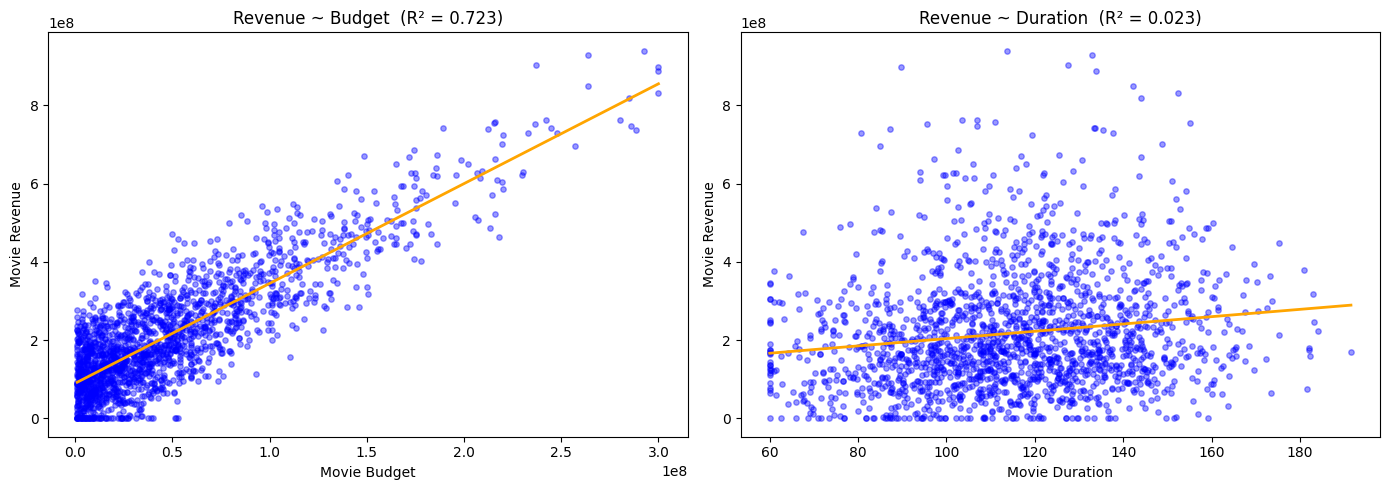

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Revenue vs Budget ---
axes[0].scatter(imdb['budget'], imdb['revenue'], alpha=0.4, s=15, color='blue')
# Regression line
budget_sorted = np.sort(imdb['budget'])
axes[0].plot(budget_sorted, 
             model_budget.params[0] + model_budget.params[1] * budget_sorted, 
             color='orange', linewidth=2)
axes[0].set_xlabel('Movie Budget')
axes[0].set_ylabel('Movie Revenue')
axes[0].set_title(f'Revenue ~ Budget  (R² = {model_budget.rsquared:.3f})')

# --- Plot 2: Revenue vs Duration ---
axes[1].scatter(imdb['duration'], imdb['revenue'], alpha=0.4, s=15, color='blue')
# Regression line
duration_sorted = np.sort(imdb['duration'])
axes[1].plot(duration_sorted, 
             model_duration.params[0] + model_duration.params[1] * duration_sorted, 
             color='orange', linewidth=2)
axes[1].set_xlabel('Movie Duration')
axes[1].set_ylabel('Movie Revenue')
axes[1].set_title(f'Revenue ~ Duration  (R² = {model_duration.rsquared:.3f})')

plt.tight_layout()
plt.show()

### R² and Causation — A Word of Caution

R² tells us how well a model **fits the data** — it says nothing about whether the relationship is **causal**.

- **Low R² doesn't mean no causal effect.** A true causal model can have a low R² simply because there are many other determinants of $Y$ besides $X$. The causal effect of $X$ on $Y$ can be real and meaningful even if $X$ only explains a small share of the overall variation.

- **High R² doesn't mean causation.** A strong correlational relationship can produce a high R² even when $E[XU] \neq 0$ (i.e., the exogeneity condition fails).

For example: Google searches for "how much wood can a woodchuck chuck" and kerosene consumption in Venezuela have an R² of about 0.80 — obviously not causal!

**Bottom line:** R² is useful for evaluating *descriptive/predictive* fit, but it cannot validate or invalidate a *causal* interpretation of a regression.

---

## Training/Test Splits & Out-of-Sample Evaluation

R² measures how well a model fits the data it was estimated on. But what we often care about is: **will the model predict well on new data it hasn't seen?**

### The Idea

1. **Randomly split** your dataset into two pieces:
   - **Training set**: used to estimate the model (e.g., 80% of the data)
   - **Test set**: "held out" during estimation (e.g., 20% of the data)

2. **Estimate** the model (e.g., OLS) using only the training set

3. **Evaluate** the model's predictions on the test set — since these observations were never used in estimation, this mimics applying the model to genuinely new data

### Mean Squared Error (MSE)

We measure out-of-sample performance with the **Mean Squared Error**:

$$\text{MSE} = \frac{1}{n_{\text{test}}} \sum_{i \in \text{test}} (\hat{Y}_i - Y_i)^2$$

Same idea as SSR — how much variation was **not** captured by the model — but now evaluated on data the model has never seen. Lower MSE = better predictive performance.



In [4]:
from sklearn.model_selection import train_test_split

# 80/20 split
train, test = train_test_split(imdb, test_size=0.20, random_state=42)

print(f"Training set: {len(train)} observations")
print(f"Test set:     {len(test)} observations")

# --- Estimate both models on the training set only ---
# Model 1: Revenue ~ Budget
X_train_budget = sm.add_constant(train['budget'])
model_budget_train = sm.OLS(train['revenue'], X_train_budget).fit()

# Model 2: Revenue ~ Duration
X_train_duration = sm.add_constant(train['duration'])
model_duration_train = sm.OLS(train['revenue'], X_train_duration).fit()

# --- Evaluate on the test set ---
# Predicted values in the test set
yhat_budget_test = model_budget_train.params[0] + model_budget_train.params[1] * test['budget']
yhat_duration_test = model_duration_train.params[0] + model_duration_train.params[1] * test['duration']

# MSE
mse_budget = np.mean((yhat_budget_test - test['revenue'])**2)
mse_duration = np.mean((yhat_duration_test - test['revenue'])**2)

print(f"\n=== Out-of-Sample MSE ===")
print(f"Revenue ~ Budget:   MSE = {mse_budget:.3e}")
print(f"Revenue ~ Duration: MSE = {mse_duration:.3e}")
print(f"\nThe budget model has {'lower' if mse_budget < mse_duration else 'higher'} MSE → better out-of-sample prediction")

Training set: 1472 observations
Test set:     369 observations

=== Out-of-Sample MSE ===
Revenue ~ Budget:   MSE = 6.368e+15
Revenue ~ Duration: MSE = 2.290e+16

The budget model has lower MSE → better out-of-sample prediction


---

## 3. Multiple Linear Regression

Everything so far has been **simple linear regression** — one regressor. Now we generalize to **multiple linear regression (MLR)**, where we have $k$ regressors:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k + \varepsilon$$

### Vector Notation

For concision, we stack everything into vectors:

$$\mathbf{X} = \begin{pmatrix} 1 \\ X_1 \\ X_2 \\ \vdots \\ X_k \end{pmatrix}, \qquad \boldsymbol{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \vdots \\ \beta_k \end{pmatrix}$$

Notice the constant 1 is included in $\mathbf{X}$. Using matrix multiplication, the model can be written compactly as:

$$Y = \mathbf{X}'\boldsymbol{\beta} + \varepsilon$$

which is exactly equivalent to the expanded form above.

### Interpretation

The MLR parameters have the same two interpretations as in SLR, just generalized:

- **Best Linear Predictor**: $\boldsymbol{\beta}$ minimizes $E[(Y - \mathbf{X}'\mathbf{B})^2]$ — predicts $Y$ as well as possible given a linear function of the $X$'s
- **Best Linear Approximation to CEF**: $\boldsymbol{\beta}$ minimizes $E[(E[Y|\mathbf{X}] - \mathbf{X}'\mathbf{B})^2]$ — approximates the conditional expectation function as closely as possible

As in SLR, these two characterizations yield the same $\boldsymbol{\beta}$.

### Why Multiple Regressors?

If we want to predict some outcome $Y$, having more predictor variables — more information — will often improve our predictions. For example, predicting NYC home prices using *both* size and distance from Midtown will presumably do better than using either one alone.

In [5]:
# Simulate NYC housing data matching the lecture's example
np.random.seed(123)
n_houses = 500

# Number of bathrooms (1, 2, 3, or 4)
bathrooms = np.random.choice([1, 2, 3, 4], size=n_houses, p=[0.45, 0.40, 0.12, 0.03])

# House area (sq ft) — correlated with bathrooms
area = 3000 + 1200 * bathrooms + np.random.normal(0, 1800, size=n_houses)
area = np.clip(area, 1500, 17000)

# Home price — depends on both area and bathrooms (plus noise)
price = (200000 
         + 390 * area 
         + 500000 * bathrooms 
         + np.random.normal(0, 1000000, size=n_houses))
price = np.clip(price, 100000, None)

housing = pd.DataFrame({
    'price': price,
    'area': area,
    'bathrooms': bathrooms
})

housing.head()

,price,area,bathrooms
0,4.776990e+06,4516.249891,2
1,1.166216e+06,1843.502434,1
2,2.039916e+06,4184.411160,1
3,3.874791e+06,7158.263368,2
4,1.974358e+06,2248.073371,2


In [6]:
# --- SLR: Price ~ Area ---
X_area = sm.add_constant(housing['area'])
slr_area = sm.OLS(housing['price'], X_area).fit()

print("=== SLR: Price ~ Area ===")
print(f"Coefficient on Area: {slr_area.params[1]:.0f}")
print(f"R² = {slr_area.rsquared:.3f}\n")

# --- MLR: Price ~ Area + Bathrooms ---
X_mlr = sm.add_constant(housing[['area', 'bathrooms']])
mlr_model = sm.OLS(housing['price'], X_mlr).fit()

print("=== MLR: Price ~ Area + Bathrooms ===")
print(f"Coefficient on Area:      {mlr_model.params[1]:.0f}")
print(f"Coefficient on Bathrooms: {mlr_model.params[2]:.0f}")
print(f"R² = {mlr_model.rsquared:.3f}")

=== SLR: Price ~ Area ===
Coefficient on Area: 486
R² = 0.506

=== MLR: Price ~ Area + Bathrooms ===
Coefficient on Area:      389
Coefficient on Bathrooms: 495941
R² = 0.568


In [7]:
print(f"\nKey comparison:")
print(f"  SLR coefficient on Area: {slr_area.params[1]:.0f}")
print(f"  MLR coefficient on Area: {mlr_model.params[1]:.0f}")
print(f"\nThe coefficient on area SHRANK in the MLR because part of area's")
print(f"explanatory power was absorbed by bathrooms (which is correlated with area).")


Key comparison:
  SLR coefficient on Area: 486
  MLR coefficient on Area: 389

The coefficient on area SHRANK in the MLR because part of area's
explanatory power was absorbed by bathrooms (which is correlated with area).


---

## Frisch-Waugh-Lovell Theorem

In an MLR model with multiple regressors, how do we interpret a single coefficient $\beta_j$?

### The Theorem

Consider the MLR model:

$$\text{Price} = \beta_0 + \beta_1 \cdot \text{Area} + \beta_2 \cdot \text{Bathrooms} + \varepsilon$$

The Frisch-Waugh-Lovell (FWL) Theorem says that $\beta_1$ in this MLR is **exactly equal** to $\beta_1$ in the following two-step procedure:

**Step 1:** Regress Area on all the *other* regressors (here, just Bathrooms):

$$\text{Area} = \beta_0^S + \beta_1^S \cdot \text{Bathrooms} + \varepsilon^S$$

and collect the residuals $\varepsilon^S$ — the part of Area that **cannot be predicted** by Bathrooms.

**Step 2:** Regress Price on these residuals:

$$\text{Price} = \beta_0^* + \beta_1 \cdot \varepsilon^S + \varepsilon^*$$

The coefficient $\beta_1$ here is identical to $\beta_1$ in the original MLR.

### Intuition

Each slope coefficient in an MLR captures the **unique** relationship between that regressor and $Y$ — the part of $X_j$'s association with $Y$ that isn't shared with the other regressors.

This is why the coefficient on Area shrank when we added Bathrooms: some of Area's explanatory power was "shared" with Bathrooms (bigger houses tend to have more bathrooms), and the MLR coefficient only reflects Area's *unique* contribution.

In [12]:
# === Frisch-Waugh-Lovell: Step by Step ===

# Step 1: Regress Area on Bathrooms → get residuals
X_bath = sm.add_constant(housing['bathrooms'])
area_on_bath = sm.OLS(housing['area'], X_bath).fit()
residuals_area = area_on_bath.resid  # εˢ — the part of Area not explained by Bathrooms

print("Step 1: Area ~ Bathrooms")
print(f"  Coefficient on Bathrooms: {area_on_bath.params.iloc[1]:.0f}")
print(f"  (Bigger houses tend to have more bathrooms)\n")

# Step 2: Regress Price on the residualized Area
X_resid = sm.add_constant(residuals_area)
fwl_model = sm.OLS(housing['price'], X_resid).fit()

print("Step 2: Price ~ Residualized Area")
print(f"  FWL coefficient on residualized Area: {fwl_model.params.iloc[1]:.0f}\n")

# Compare
print("=== Comparison ===")
print(f"  MLR coefficient on Area: {mlr_model.params.iloc[1]:.0f}")
print(f"  FWL coefficient on Area: {fwl_model.params.iloc[1]:.0f}")


Step 1: Area ~ Bathrooms
  Coefficient on Bathrooms: 1260
  (Bigger houses tend to have more bathrooms)

Step 2: Price ~ Residualized Area
  FWL coefficient on residualized Area: 389

=== Comparison ===
  MLR coefficient on Area: 389
  FWL coefficient on Area: 389


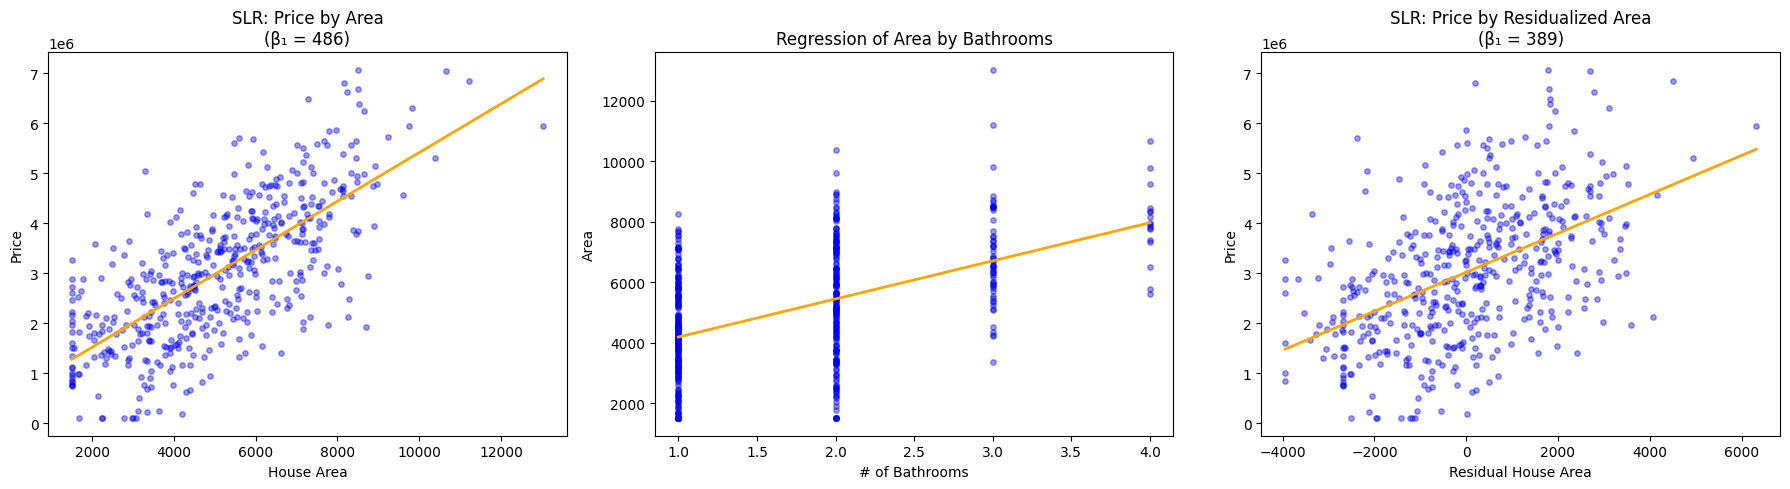

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: SLR — Price vs Area ---
axes[0].scatter(housing['area'], housing['price'], alpha=0.4, s=15, color='blue')
area_sorted = np.sort(housing['area'])
axes[0].plot(area_sorted, 
             slr_area.params.iloc[0] + slr_area.params.iloc[1] * area_sorted, 
             color='orange', linewidth=2)
axes[0].set_xlabel('House Area')
axes[0].set_ylabel('Price')
axes[0].set_title(f'SLR: Price by Area\n(β₁ = {slr_area.params.iloc[1]:.0f})')

# --- Plot 2: Area vs Bathrooms ---
axes[1].scatter(housing['bathrooms'], housing['area'], alpha=0.4, s=15, color='blue')
bath_sorted = np.sort(housing['bathrooms'].unique())
axes[1].plot(bath_sorted, 
             area_on_bath.params.iloc[0] + area_on_bath.params.iloc[1] * bath_sorted, 
             color='orange', linewidth=2)
axes[1].set_xlabel('# of Bathrooms')
axes[1].set_ylabel('Area')
axes[1].set_title('Regression of Area by Bathrooms')

# --- Plot 3: Price vs Residualized Area ---
axes[2].scatter(residuals_area, housing['price'], alpha=0.4, s=15, color='blue')
resid_sorted = np.sort(residuals_area)
axes[2].plot(resid_sorted, 
             fwl_model.params.iloc[0] + fwl_model.params.iloc[1] * resid_sorted, 
             color='orange', linewidth=2)
axes[2].set_xlabel('Residual House Area')
axes[2].set_ylabel('Price')
axes[2].set_title(f'SLR: Price by Residualized Area\n(β₁ = {fwl_model.params.iloc[1]:.0f})')

plt.tight_layout()
plt.show()

---

## Key Takeaways

**Part A — R² and Model Fit:**
- R² measures the proportion of variation in $Y$ explained by the model: $R^2 = 1 - \text{SSR}/\text{TSS}$
- R² = 1 means perfect fit (every point on the line); R² = 0 means the model has no explanatory power ($\hat{\beta}_1 = 0$)
- **R² says nothing about causation.** A high R² can arise from spurious correlation, and a true causal model can have a low R²
- R² is an *in-sample* measure — it tells you how well the model fits the data it was trained on, not how well it will predict new data

**Part B — Training/Test Splits & Out-of-Sample Evaluation:**
- To evaluate *predictive* performance, split the data into a training set (used for estimation) and a test set (held out)
- **MSE** on the test set measures how well the model generalizes to new data — lower is better
- Common splits: 80/20 or 75/25 for small datasets; 95/99 for very large datasets
- This approach guards against **overfitting** — a model fitting noise in the training data rather than the true relationship (more on this with MLR later)

**Part C — Multiple Linear Regression:**
- MLR generalizes SLR to multiple regressors: $Y = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k + \varepsilon$
- In vector notation: $Y = \mathbf{X}'\boldsymbol{\beta} + \varepsilon$
- Including more relevant features generally improves prediction — more information to work with
- The BLP and BLA interpretations carry over from SLR identically

**Part D — Frisch-Waugh-Lovell:**
- Each MLR slope coefficient $\beta_j$ captures the **unique** relationship between $X_j$ and $Y$ — after removing the variation $X_j$ shares with the other regressors
- FWL gives a two-step procedure: (1) regress $X_j$ on all other regressors, collect residuals; (2) regress $Y$ on those residuals — the slope equals the MLR coefficient
- This is why coefficients can "shrink" when adding correlated regressors — the MLR only credits each variable for its unique contribution
- Key intuition: in the housing example, the SLR coefficient on Area ($\approx 462$) shrank in the MLR ($\approx 390$) because part of Area's explanatory power was shared with Bathrooms

---

## Office Hours Friday 11 AM - 1 PM  Room No - 244
or dropin your questions at vka244@nyu.edu

---